# 04 · optimizer의 계산

**이번 질문:** 같은 기울기를 받아도 SGD·Momentum·RMSProp·Adam은 왜 다른 파라미터를 만들까요?

[01](01_gradients_and_learning.ipynb)의 미분·갱신을 출발점으로 삼고, [02](02_probability_and_losses.ipynb)의 기댓값과 [03](03_perceptron_to_mlp.ipynb)의 역전파를 연결합니다.
작은 벡터의 한두 스텝을 먼저 손으로 계산하고, 그 함수 그대로 회귀를 학습합니다.

- 1–2절: 기울기·학습률·미니배치의 의미
- 3–6절: 네 optimizer의 수식·상태·한두 스텝 검산
- 7–9절: 학습 경로·실제 회귀·초기화와 기울기 크기
- 10절: 상태를 유지하는 구현과 직접 변형 문제

모든 optimizer·학습·초기화 계산을 본문에서 수행합니다.
[셀 실행 안내](../../README.md) · [전체 경로](../../docs/CURRICULUM.md) · [그림 보조 코드](../../src/utils/optimizer_plots.py)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "utils" / "plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src import check_function
from src.utils.optimizer_plots import (
    plot_batch_gradients, plot_moments, plot_optimizer_paths,
    plot_regression_runs, plot_initialization, plot_schedule,
)
setup_plots()
np.set_printoptions(precision=6, suppress=True)
print("NumPy", np.__version__, "· optimizer 준비 완료")

NumPy 2.3.5 · optimizer 준비 완료


## 1. 기울기와 업데이트를 구분합니다

파라미터를 벡터 $\theta$로 모으면 기울기 $g=\nabla_\theta J$도 같은 shape입니다.
기울기는 손실의 국소 변화율이며, optimizer는 이 값과 이전 상태로 **실제 변화량**을 정합니다.
가장 기본적인 경사하강은 $\theta_{t+1}=\theta_t-\eta g_t$입니다.

예를 들어 $J(\theta)=\tfrac12(\theta_0^2+20\theta_1^2)$이면 $g=(\theta_0,20\theta_1)$입니다.
두 번째 방향은 같은 변화에도 기울기가 더 빨리 변합니다. 이 곡률은 각 방향의 이차미분인 1과 20입니다.

1차원 $J(w)=aw^2/2$의 갱신을 정리하면 $w_{t+1}=(1-\eta a)w_t$입니다.
$w_t$의 크기가 줄려면 $|1-\eta a|<1$, 즉 $0<\eta<2/a$여야 합니다.
이 양의 이차식에서 얻은 조건이 모든 비선형 신경망에 그대로 적용되는 것은 아닙니다.

In [2]:
def quadratic(theta):
    curvature = np.array([1., 20.])
    return 0.5 * np.sum(curvature * theta**2), curvature * theta

In [3]:
theta_start = np.array([3., 1.])
start_loss, start_gradient = quadratic(theta_start)
np.testing.assert_allclose([start_loss, *start_gradient], [14.5, 3., 20.])
quadratic_error = check_function(
    lambda theta: np.array(quadratic(theta)[0]),
    lambda dout, theta: dout * quadratic(theta)[1],
    theta_start, dout=np.array(1.), verbose=True, name="이차 목적의 기울기",
)
for rate in (0.05, 0.11):
    updated = theta_start - rate * start_gradient
    print(f"η={rate}: θ={updated}, J={quadratic(updated)[0]:.6f}")

[gradcheck] 이차 목적의 기울기
  ok   dx  rel_err = 2.097e-11
η=0.05: θ=[2.85 0.  ], J=4.061250
η=0.11: θ=[ 2.67 -1.2 ], J=17.964450


## 2. 미니배치: 어떤 표본의 기울기를 평균낼까요?

회귀의 절반 MSE를 $J(\theta)=\frac1N\sum_n\ell_n(\theta)$로 놓으면
$\nabla J=\frac1N\sum_n\nabla\ell_n$입니다. 같은 $\theta$에서 계산한 **각 표본의 기울기를 평균**냅니다.

회귀 입력을 $F_n=[x_n,1]$, 파라미터를 $\theta=[w,b]$로 모읍니다.
$\hat y=F\theta$, $r=\hat y-y$이며, 표본 기울기는 $r_nF_n$, 전체 기울기는 $F^\top r/N$입니다.
`F.shape=(N,2)`, `y.shape=(N,)`, `theta.shape=(2,)`입니다.

에폭(epoch)은 학습 데이터를 한 번 모두 사용하는 단위이고, 스텝(step)은 파라미터를 한 번 갱신하는 단위입니다.
배치 크기가 B이면 한 에폭의 스텝 수는 $\lceil N/B\rceil$이며 마지막 배치는 작을 수 있습니다.

In [4]:
def regression_loss_gradient(features, targets, theta):
    residual = features @ theta - targets
    return 0.5 * np.mean(residual**2), features.T @ residual / len(targets)


def epoch_batches(size, batch_size, rng):
    assert batch_size > 0
    order = rng.permutation(size)
    return [order[start:start+batch_size] for start in range(0, size, batch_size)]

In [5]:
x_small = np.array([-2., -1., 0., 1., 2., 3.])
F_small = np.column_stack([x_small, np.ones(len(x_small))])
y_small = 2*x_small - 0.3
theta_small = np.array([0., 0.])
_, full_gradient = regression_loss_gradient(F_small, y_small, theta_small)
per_sample = (F_small @ theta_small - y_small)[:, None] * F_small
np.testing.assert_allclose(full_gradient, per_sample.mean(axis=0))
batches = epoch_batches(len(x_small), 4, np.random.default_rng(8))
assert [len(batch) for batch in batches] == [4, 2]
np.testing.assert_array_equal(np.sort(np.concatenate(batches)), np.arange(6))
weighted_gradient = np.zeros(2)
unweighted_gradient = np.zeros(2)
for batch in batches:
    gradient = regression_loss_gradient(F_small[batch], y_small[batch], theta_small)[1]
    weighted_gradient += len(batch) / len(x_small) * gradient
    unweighted_gradient += gradient / len(batches)
np.testing.assert_allclose(weighted_gradient, full_gradient)
print("전체 기울기", full_gradient)
print("배치 평균에 표본 수 가중치 적용", weighted_gradient)
print("크기 다른 배치 평균끼리 단순 평균", unweighted_gradient)

전체 기울기 [-6.183333 -0.7     ]
배치 평균에 표본 수 가중치 적용 [-6.183333 -0.7     ]
크기 다른 배치 평균끼리 단순 평균 [-5.5625 -0.95  ]


위 항등식은 **같은 파라미터를 고정한 채** 계산한 결과입니다.
실제 미니배치 학습은 배치마다 파라미터를 바꾸므로 한 에폭의 갱신은 전체 기울기로 한 번 갱신하는 것과 다릅니다.

아래에서는 이 여섯 표본의 인덱스를 독립·균등하게 **복원추출**합니다. 배치 평균의 기댓값은 전체 기울기이고,
각 좌표의 분산은 원래 표본 기울기 분산의 $1/B$입니다. 표준편차는 $1/\sqrt B$배입니다.
이 실험의 복원추출과, 한 에폭에서 중복 없이 섞는 학습 코드를 구분합니다.

In [6]:
rng_batch = np.random.default_rng(40)
batch_sizes = np.array([1, 2, 4, 8, 16])
observed_std = []
expected_std = []
for batch_size in batch_sizes:
    indices = rng_batch.integers(0, len(x_small), size=(2000, batch_size))
    estimates = per_sample[indices].mean(axis=1)  # (2000,2): 배치 2000개의 평균 기울기
    observed_std.append(estimates[:, 0].std())
    expected_std.append(per_sample[:, 0].std() / np.sqrt(batch_size))
print("배치 크기", batch_sizes, "· 관측 표준편차", np.array(observed_std))

배치 크기 [ 1  2  4  8 16] · 관측 표준편차 [5.648146 4.146826 2.880184 2.046016 1.464832]


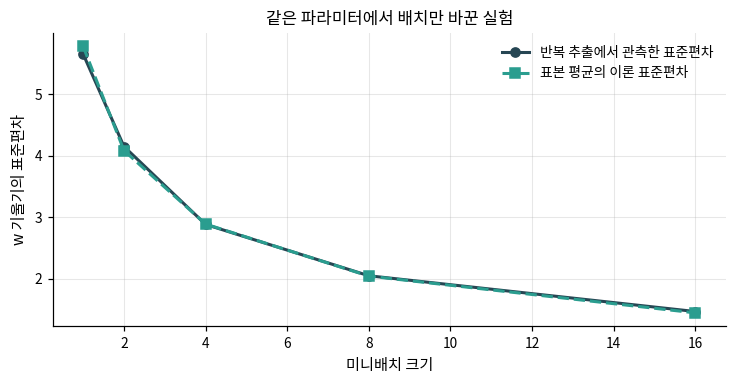

In [7]:
plot_batch_gradients(batch_sizes, observed_std, expected_std)

## 3. SGD: 현재 배치의 기울기를 그대로 사용합니다

$$\theta_{t+1}=\theta_t-\eta g_t.$$

SGD(stochastic gradient descent)의 확률성은 선택한 표본에서 옵니다. 아래 갱신 함수를 전체 데이터 기울기에 적용하면 full-batch gradient descent가 됩니다.
`state`는 업데이트 사이에 기억할 값을 담는 딕셔너리입니다. SGD에서는 기록용 스텝 수만 보관합니다.
함수는 새 파라미터와 새 상태를 반환하며, 입력 배열을 직접 덮어쓰지 않습니다.

In [8]:
def sgd_step(theta, gradient, state, learning_rate):
    updated = theta - learning_rate * gradient
    return updated, {"t": state.get("t", 0) + 1}

In [9]:
initial = np.array([1., -2.])
g1 = np.array([2., -4.])
g2 = np.array([-1., 2.])
sgd_first, sgd_state = sgd_step(initial, g1, {}, 0.1)
sgd_second, sgd_state = sgd_step(sgd_first, g2, sgd_state, 0.1)
np.testing.assert_allclose(sgd_first, [0.8, -1.6])
np.testing.assert_allclose(sgd_second, [0.9, -1.8])
np.testing.assert_array_equal(initial, [1., -2.])
print("SGD 1회", sgd_first, "2회", sgd_second, "상태", sgd_state)

SGD 1회 [ 0.8 -1.6] 2회 [ 0.9 -1.8] 상태 {'t': 2}


## 4. Momentum: 이전 기울기의 방향을 기억합니다

여기서는 다음 정의를 씁니다.

$$v_t=\beta v_{t-1}+g_t,\qquad\theta_t=\theta_{t-1}-\eta v_t,\qquad v_0=0.$$

$\beta\in[0,1)$는 이전 값의 유지 비율입니다. $v_2=\beta g_1+g_2$를 펼쳐 보면 이전 기울기가 남는 것을 볼 수 있습니다.
방향이 일관되면 기여가 쌓이고, 번갈아 바뀌면 일부 상쇄됩니다.
다른 자료에서는 $(1-\beta)g_t$를 사용하는 이동 평균 형태도 씁니다. 이 노트북의 Momentum은 위 식이며 Adam의 1차 모멘트와 계수가 다릅니다.

첫 두 기울기가 `(2,-4)`, `(-1,2)`이고 $\beta=0.9$이면 $v_1=(2,-4)$, $v_2=(0.8,-1.6)$입니다.

In [10]:
def momentum_step(theta, gradient, state, learning_rate, beta=0.9):
    velocity = beta * state.get("velocity", np.zeros_like(theta)) + gradient
    updated = theta - learning_rate * velocity
    return updated, {"velocity": velocity, "t": state.get("t", 0) + 1}

In [11]:
momentum_first, momentum_state = momentum_step(initial, g1, {}, 0.1)
momentum_second, momentum_state = momentum_step(momentum_first, g2, momentum_state, 0.1)
np.testing.assert_allclose(momentum_first, [0.8, -1.6])
np.testing.assert_allclose(momentum_state["velocity"], [0.8, -1.6])
np.testing.assert_allclose(momentum_second, [0.72, -1.44])
np.testing.assert_allclose(momentum_step(initial, g1, {}, 0.1, beta=0)[0], sgd_first)
print("Momentum 1회", momentum_first, "2회", momentum_second, "· v", momentum_state["velocity"])

Momentum 1회 [ 0.8 -1.6] 2회 [ 0.72 -1.44] · v [ 0.8 -1.6]


## 5. RMSProp: 좌표별 기울기 크기를 기억합니다

$$s_t=\rho s_{t-1}+(1-\rho)g_t^2,\qquad
\theta_t=\theta_{t-1}-\eta\frac{g_t}{\sqrt{s_t}+\epsilon}.$$

제곱과 나눗셈은 **원소별**입니다. `s.shape == theta.shape`이며, 크기가 큰 기울기가 계속 나온 좌표는 큰 분모를 갖습니다.
$s_t$는 제곱의 이동 평균인 **2차 원시 모멘트**입니다. 평균의 제곱을 빼지 않았으므로 분산 자체와 구분합니다.
$\epsilon$은 0 나누기를 피하는 작은 양수입니다. 구현 변형 중 여기서는 제곱근 **밖**에 더합니다.

$\rho=0.9$와 $g_1=(2,-4)$라면 $s_1=(0.4,1.6)$입니다.
다음 $g_2=(-1,2)$에서는 $s_2=0.9(0.4,1.6)+0.1(1,4)=(0.46,1.84)$입니다.

In [12]:
def rmsprop_step(theta, gradient, state, learning_rate, rho=0.9, epsilon=1e-8):
    square = rho * state.get("square", np.zeros_like(theta)) + (1-rho) * gradient**2
    updated = theta - learning_rate * gradient / (np.sqrt(square) + epsilon)
    return updated, {"square": square, "t": state.get("t", 0) + 1}

In [13]:
# 이 손계산에서는 두 좌표의 분모가 양수이므로 epsilon=0으로 비교합니다.
rms_first, rms_state = rmsprop_step(initial, g1, {}, 0.1, epsilon=0)
np.testing.assert_allclose(rms_state["square"], [0.4, 1.6])
np.testing.assert_allclose(rms_first, [0.683772233983162, -1.683772233983162])
rms_second, rms_state = rmsprop_step(rms_first, g2, rms_state, 0.1, epsilon=0)
np.testing.assert_allclose(rms_state["square"], [0.46, 1.84])
zero_result, _ = rmsprop_step(initial, np.zeros(2), {}, 0.1)  # 실제 기본값은 양의 epsilon
np.testing.assert_array_equal(zero_result, initial)
print("RMSProp 1회", rms_first, "2회", rms_second, "· s", rms_state["square"])

RMSProp 1회 [ 0.683772 -1.683772] 2회 [ 0.831214 -1.831214] · s [0.46 1.84]


## 6. Adam: 1·2차 모멘트를 함께 쓰고 초기 편향을 보정합니다

Adam은 기울기의 이동 평균 $m_t$와 제곱의 이동 평균 $s_t$를 저장합니다.

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,\qquad
s_t=\beta_2s_{t-1}+(1-\beta_2)g_t^2.$$

0에서 시작했기 때문에 초반의 이동 평균은 작아집니다. 기울기가 항상 g라면
$m_t=(1-\beta_1)(1+\beta_1+\cdots+\beta_1^{t-1})g=(1-\beta_1^t)g$입니다.
이 계수로 나누어 초기값 0 때문에 생긴 편향을 보정합니다.

$$\hat m_t=\frac{m_t}{1-\beta_1^t},\quad\hat s_t=\frac{s_t}{1-\beta_2^t},\quad
\theta_t=\theta_{t-1}-\eta\frac{\hat m_t}{\sqrt{\hat s_t}+\epsilon}.$$

`t`는 1부터 세는 **업데이트 횟수**입니다. 에폭 수가 아니며, 모멘트와 함께 계속 유지해야 합니다.
이 보정은 학습 데이터나 모델 추정 전체의 편향을 제거한다는 뜻이 아닙니다.
아래 코드는 [Adam 원 논문의 Algorithm 1](https://arxiv.org/pdf/1412.6980)의 보정 후 분모 정의를 사용합니다.

In [14]:
def adam_step(theta, gradient, state, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
    t = state.get("t", 0) + 1
    mean = beta1 * state.get("mean", np.zeros_like(theta)) + (1-beta1) * gradient
    square = beta2 * state.get("square", np.zeros_like(theta)) + (1-beta2) * gradient**2
    corrected_mean = mean / (1-beta1**t)
    corrected_square = square / (1-beta2**t)
    updated = theta - learning_rate * corrected_mean / (np.sqrt(corrected_square) + epsilon)
    return updated, {"mean": mean, "square": square, "t": t}

In [15]:
# 손계산을 쉽게 하려고 두 beta를 0.5로 놓고, 양수 분모에서 epsilon=0으로 비교합니다.
a0 = np.array([1.])
a1, state1 = adam_step(a0, np.array([2.]), {}, 0.1, beta1=0.5, beta2=0.5, epsilon=0)
a2, state2 = adam_step(a1, np.array([-2.]), state1, 0.1, beta1=0.5, beta2=0.5, epsilon=0)
# t=1: m=1, s=2, 보정 후 m=2, s=4 → 0.1만큼 감소
np.testing.assert_allclose([*state1["mean"], *state1["square"], *a1], [1., 2., 0.9])
# t=2: m=-0.5, s=3, 보정 후 m=-2/3, s=4 → 1/30만큼 증가
np.testing.assert_allclose([*state2["mean"], *state2["square"], *a2], [-0.5, 3., 14/15])
assert state2["t"] == 2
np.testing.assert_allclose(adam_step(initial, np.zeros(2), {}, 0.1)[0], initial)
print("Adam 1회", a1, "2회", a2, "· 2회 상태", state2)

Adam 1회 [0.9] 2회 [0.933333] · 2회 상태 {'mean': array([-0.5]), 'square': array([3.]), 't': 2}


In [16]:
constant_gradient = np.array([2.])
constant_theta = np.array([0.])
constant_state = {}
raw_mean, corrected_mean, raw_square, corrected_square = [], [], [], []
for t in range(1, 21):
    constant_theta, constant_state = adam_step(constant_theta, constant_gradient, constant_state, 0.1)
    raw_mean.append(constant_state["mean"][0])
    corrected_mean.append(constant_state["mean"][0] / (1-0.9**t))
    raw_square.append(constant_state["square"][0])
    corrected_square.append(constant_state["square"][0] / (1-0.999**t))
np.testing.assert_allclose(corrected_mean, 2.)
np.testing.assert_allclose(corrected_square, 4.)

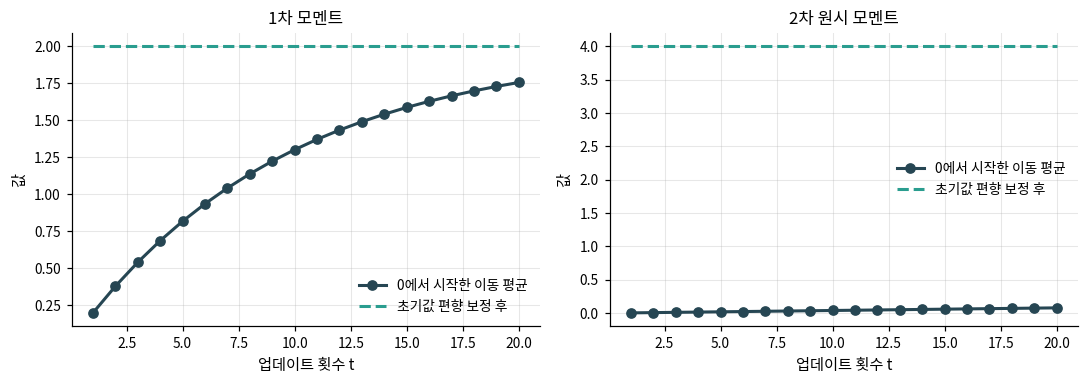

In [17]:
plot_moments(np.arange(1, 21), raw_mean, corrected_mean, raw_square, corrected_square)

일정한 기울기에서 보정 후 값이 2와 4를 복원합니다. 실제 학습에서는 기울기도 바뀌므로 곡선이 이처럼 일정할 필요는 없습니다.
SGD·Momentum·RMSProp·Adam의 차이를 이름 대신 **어떤 배열을 다음 스텝까지 기억하는가**로 정리할 수 있습니다.

| 방법 | 유지할 상태 | 이번 갱신에 사용한 방향 |
|---|---|---|
| SGD | 계산에 필요한 누적 상태 없음 | 현재 g |
| Momentum | 이전 기울기의 가중합 v | v |
| RMSProp | 제곱 이동 평균 s | g를 좌표별 크기로 나눈 값 |
| Adam | 이동 평균 m·s, 스텝 t | 보정한 m을 보정한 제곱 크기로 나눈 값 |

## 7. 같은 이차 목적에서 경로를 비교합니다

1절의 목적·초기값을 고정하고 120회 갱신합니다.
비교에는 각 방법의 학습률도 함께 표시합니다. 같은 숫자의 학습률이 서로 같은 변화량을 뜻하지 않으므로,
이 한 설정을 optimizer의 보편적인 순위로 해석하지 않습니다.
`history['theta'][t]`와 `history['loss'][t]`는 같은 시점의 파라미터와 목적값입니다.

In [18]:
def run_quadratic(step_function, learning_rate, steps=120):
    theta = theta_start.copy()
    state = {}
    history = {"theta": [theta.copy()], "loss": [quadratic(theta)[0]]}
    for t in range(steps):
        _, gradient = quadratic(theta)
        theta, state = step_function(theta, gradient, state, learning_rate)
        history["theta"].append(theta.copy())
        history["loss"].append(quadratic(theta)[0])
    return {key: np.array(value) for key, value in history.items()}

In [19]:
optimizer_specs = {
    "SGD η=0.08": (sgd_step, 0.08),
    "Momentum η=0.03": (momentum_step, 0.03),
    "RMSProp η=0.08": (rmsprop_step, 0.08),
    "Adam η=0.08": (adam_step, 0.08),
}
quadratic_histories = {}
for name, (step_function, rate) in optimizer_specs.items():
    history = run_quadratic(step_function, rate)
    assert np.all(np.isfinite(history["loss"]))
    assert history["loss"][-1] < history["loss"][0]
    quadratic_histories[name] = history
    print(name, "· 마지막 목적값", history["loss"][-1])
# 격자의 행은 둘째 파라미터, 열은 첫 파라미터의 후보입니다.
# xx·yy·surface.shape=(100,100). 학습 계산은 위 루프에서 수행했습니다.
xx, yy = np.meshgrid(np.linspace(-1.2, 3.4, 100), np.linspace(-1.3, 1.3, 100))
surface = 0.5 * (xx**2 + 20 * yy**2)

SGD η=0.08 · 마지막 목적값 9.168347733964372e-09
Momentum η=0.03 · 마지막 목적값 1.5808498185671706e-05
RMSProp η=0.08 · 마지막 목적값 0.036501099256119836
Adam η=0.08 · 마지막 목적값 6.339187231575337e-05


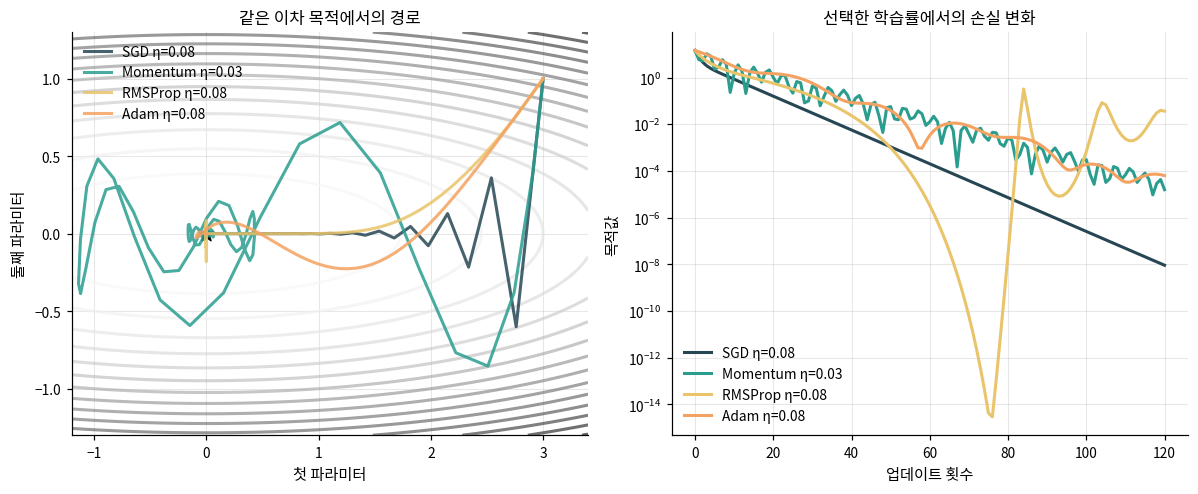

In [20]:
plot_optimizer_paths(xx, yy, surface, quadratic_histories)

모멘텀의 누적과 적응형 분모 때문에 같은 목적에서도 경로가 달라집니다.
최솟값 가까이에서 진동하거나 잠시 손실이 커지는 것도 볼 수 있습니다. 각 스텝이 반드시 손실을 줄이는 방법들이라는 뜻은 아닙니다.

## 8. 실제 회귀: 같은 초기값과 배치 순서로 비교합니다

$y=1.7x-0.4+\text{잡음}$ 데이터를 만들고 네 방법으로 학습합니다.
배치 크기는 16, 표본은 65개이므로 마지막 배치는 1개입니다. 이 작은 배치도 실제 크기로 평균냅니다.
모든 방법에 **같은 미리 만든 인덱스 순서**, 같은 초기값을 전달합니다.
기록할 손실은 매 스텝 전체 학습셋에서 계산하며, 업데이트 기울기는 현재 배치에서 계산합니다.

`seen`은 처리한 표본 수입니다. 서로 다른 배치 크기를 나중에 비교할 때는 스텝 수와 처리한 표본 수를 함께 살펴야 합니다.

In [21]:
def train_regression(features, targets, initial_theta, schedule, step_function, learning_rate):
    theta = initial_theta.copy()
    state = {}
    history = {"loss": [], "gradient_norm": [], "seen": []}
    seen = 0
    for step in range(len(schedule) + 1):
        full_loss, full_gradient = regression_loss_gradient(features, targets, theta)
        history["loss"].append(full_loss)
        history["gradient_norm"].append(np.linalg.norm(full_gradient))
        history["seen"].append(seen)
        if step == len(schedule):
            break
        batch = schedule[step]
        _, gradient = regression_loss_gradient(features[batch], targets[batch], theta)
        theta, state = step_function(theta, gradient, state, learning_rate)
        seen += len(batch)
    return theta, state, {key: np.array(value) for key, value in history.items()}

In [22]:
rng_data = np.random.default_rng(41)
x_train = np.linspace(-2, 2, 65)
features = np.column_stack([x_train, np.ones(len(x_train))])
targets = 1.7*x_train - 0.4 + rng_data.normal(0, 0.12, len(x_train))
rng_order = np.random.default_rng(42)
batch_schedule = []
for epoch in range(40):
    batch_schedule.extend(epoch_batches(len(x_train), 16, rng_order))
assert len(batch_schedule) == 200 and sum(map(len, batch_schedule)) == 65*40
initial_theta = np.array([-1., 1.])
regression_specs = {"SGD η=0.08": (sgd_step, 0.08), "Momentum η=0.03": (momentum_step, 0.03),
                    "RMSProp η=0.03": (rmsprop_step, 0.03), "Adam η=0.05": (adam_step, 0.05)}
regression_histories = {}
for name, (step_function, rate) in regression_specs.items():
    theta, state, history = train_regression(features, targets, initial_theta, batch_schedule,
                                              step_function, rate)
    assert state["t"] == len(batch_schedule)
    assert history["seen"][-1] == len(x_train) * 40
    assert history["loss"][-1] < history["loss"][0] / 10
    regression_histories[name] = history
    print(f"{name}: θ={theta}, loss={history['loss'][-1]:.6f}, steps={state['t']}")
least_squares = np.linalg.lstsq(features, targets, rcond=None)[0]
print("독립 최소제곱 해", least_squares, "· 최소 손실", regression_loss_gradient(features, targets, least_squares)[0])

SGD η=0.08: θ=[ 1.700046 -0.394376], loss=0.005942, steps=200
Momentum η=0.03: θ=[ 1.700313 -0.383934], loss=0.006081, steps=200
RMSProp η=0.03: θ=[ 1.701483 -0.345318], loss=0.007544, steps=200
Adam η=0.05: θ=[ 1.703473 -0.404286], loss=0.005918, steps=200
독립 최소제곱 해 [ 1.700257 -0.402473] · 최소 손실 0.005909222626615714


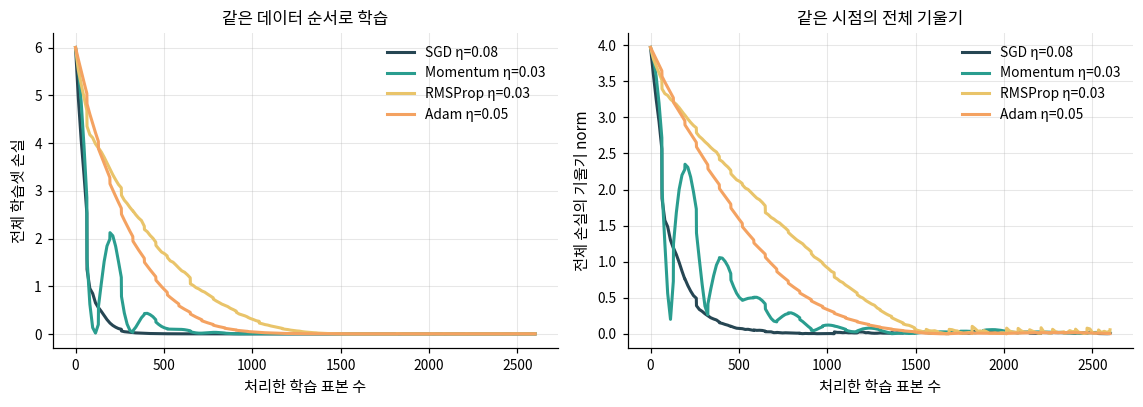

In [23]:
plot_regression_runs(regression_histories)

이 실험은 작은 선형 회귀이며 설정을 고르기 위한 대규모 성능 비교가 아닙니다.
해석할 때는 선택한 학습률, 동일한 200회 업데이트·2600개 표본 처리, 학습셋에서 측정한 손실을 함께 읽습니다.
최소제곱 해는 이 회귀 문제의 독립 기준이고, 정해진 횟수의 미니배치 업데이트가 그 해에 정확히 도달할 필요는 없습니다.

## 9. optimizer 앞뒤도 확인합니다: 초기화·기울기 크기·학습률

### 초기화의 크기는 forward와 backward 모두에 영향을 줍니다

03에서 서로 다른 초기값이 필요함을 보았습니다. 크기도 중요합니다.
가중치끼리 독립이고 평균이 0이며 같은 분산을 갖고, 가중치 벡터가 입력과 독립이라고 가정합니다.
각 입력 성분의 제곱 평균도 같다고 놓습니다. $z=\sum_{d=1}^{D}w_da_d$를 제곱해 기댓값을 취하면

$$\mathbb E[z^2]=\sum_i\mathbb E[w_i^2]\mathbb E[a_i^2]
+\sum_{i\ne j}\mathbb E[w_iw_j]\mathbb E[a_ia_j].$$

독립인 두 변수는 결합확률이 곱으로 나뉘므로
$\mathbb E[UV]=\sum_{u,v}uv\,p(u)p(v)=(\sum_u u\,p(u))(\sum_v v\,p(v))=\mathbb E[U]\mathbb E[V]$입니다.
연속 분포에서도 합을 적분으로 바꾸어 같은 관계를 얻습니다.

교차항에서는 $\mathbb E[w_iw_j]=\mathbb E[w_i]\mathbb E[w_j]=0$이므로 두 번째 합이 사라집니다.
또한 $\mathbb E[z]=0$, $\mathbb E[w_i^2]=\operatorname{Var}(w)$이므로
$\operatorname{Var}(z)=D\operatorname{Var}(w)\mathbb E[a^2]$가 됩니다.
같은 크기의 항 D개를 합한 결과가 코드에서 사용하는 `fan_in=D`와 연결됩니다.
분포가 0을 중심으로 대칭이면 ReLU가 제곱 크기의 절반을 남겨 $\mathbb E[\operatorname{ReLU}(z)^2]=\mathbb E[z^2]/2$입니다.
이 근사로 입력·출력의 제곱 크기를 비슷하게 유지하려면 $\operatorname{Var}(w)\approx2/D$, 표준편차는 $\sqrt{2/D}$를 택합니다. 이것이 여기서 쓰는 He 초기화입니다.

03의 tanh에는 Glorot 표준편차 $\sqrt{2/(d_{in}+d_{out})}$를 사용했습니다.
초기화의 전제는 실제 학습 중 모든 층에서 정확히 유지되지 않습니다. 아래 실험은 크기 변화가 어떻게 전달되는지 관찰하는 작은 진단입니다.
[He 외의 원 논문](https://arxiv.org/abs/1502.01852), [Glorot·Bengio의 원 논문](https://proceedings.mlr.press/v9/glorot10a.html).

먼저 D=2, 입력 `[1,1]`, 독립 가중치가 각각 -1 또는 1인 작은 경우를 전부 열거합니다.
네 결과가 같은 확률이면 z는 `[-2,0,0,2]`, 분산은 2이고 ReLU 출력 제곱의 평균은 1입니다.
그다음 입력은 `(256,32)`, 은닉층은 모두 너비 32인 6개 층으로 늘립니다.
forward의 활성값 제곱 평균과, 마지막 출력 합 $G=\sum A_6$에서 시작한 backward의 RMS를 계산합니다.
RMS(root mean square)는 `sqrt(mean(value**2))`입니다. G를 이렇게 정하면 마지막 상류 기울기는 모두 1입니다.
실제 분류 손실을 학습하는 대신, 동일한 상류 기울기가 각 층을 거치며 어떻게 변하는지 봅니다.

In [24]:
def inspect_initialization(X, base_weights, standard_deviation):
    weights = [base * standard_deviation for base in base_weights]
    activations = [X]
    preactivations = []
    for W in weights:
        Z = activations[-1] @ W
        preactivations.append(Z)
        activations.append(np.maximum(Z, 0))
    second_moments = [np.mean(A**2) for A in activations]
    dA = np.ones_like(activations[-1])
    gradient_rms = [None] * len(activations)
    gradient_rms[-1] = np.sqrt(np.mean(dA**2))
    for layer_index in range(len(weights) - 1, -1, -1):
        dZ = dA * (preactivations[layer_index] > 0)
        dA = dZ @ weights[layer_index].T
        gradient_rms[layer_index] = np.sqrt(np.mean(dA**2))
    return np.array(second_moments), np.array(gradient_rms)

In [25]:
weight_cases = np.array([[-1., -1.], [-1., 1.], [1., -1.], [1., 1.]])
z_cases = weight_cases @ np.ones(2)
case_probabilities = np.full(4, 0.25)
mean_z = np.sum(case_probabilities * z_cases)
variance_z = np.sum(case_probabilities * (z_cases - mean_z)**2)
relu_second_moment = np.sum(case_probabilities * np.maximum(z_cases, 0)**2)
np.testing.assert_allclose([mean_z, variance_z, relu_second_moment], [0., 2., 1.])
print("두 입력의 완전열거: Var(z)=", variance_z, "E[ReLU(z)^2]=", relu_second_moment)

rng_init = np.random.default_rng(43)
init_X = rng_init.normal(size=(256, 32))
base_weights = [rng_init.normal(size=(32, 32)) for _ in range(6)]
init_scales = {"작게": 0.1/np.sqrt(32), "He": np.sqrt(2/32), "크게": 3/np.sqrt(32)}
second_moments, gradient_rms = {}, {}
for name, scale in init_scales.items():
    moments, rms = inspect_initialization(init_X, base_weights, scale)
    assert np.all(np.isfinite(moments)) and np.all(np.isfinite(rms))
    second_moments[name], gradient_rms[name] = moments, rms
    print(f"{name}: 마지막 활성값 제곱 평균 {moments[-1]:.3e}, 입력 기울기 RMS {rms[0]:.3e}")

두 입력의 완전열거: Var(z)= 2.0 E[ReLU(z)^2]= 1.0
작게: 마지막 활성값 제곱 평균 9.196e-15, 입력 기울기 RMS 2.121e-07
He: 마지막 활성값 제곱 평균 5.885e-01, 입력 기울기 RMS 1.697e+00
크게: 마지막 활성값 제곱 평균 4.887e+03, 입력 기울기 RMS 1.546e+02


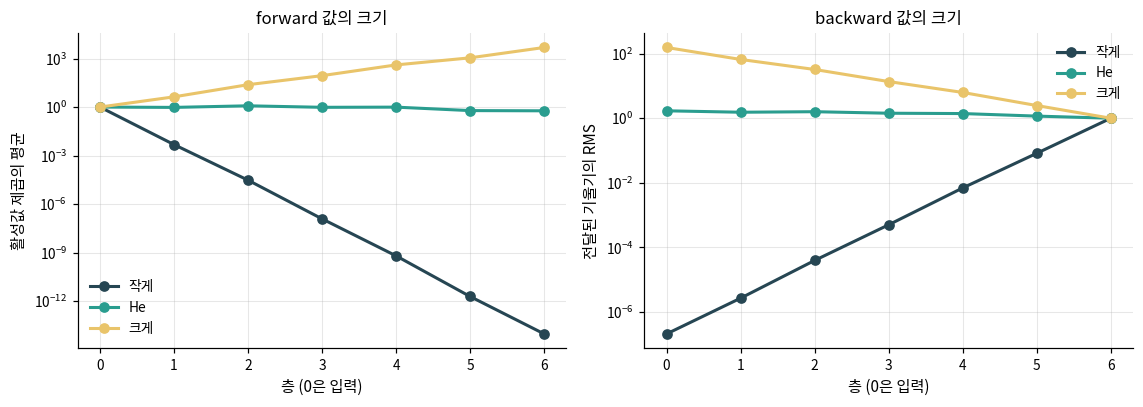

In [26]:
plot_initialization(np.arange(7), second_moments, gradient_rms)

큰 크기 차이는 optimizer를 고르기 전에 생겼습니다. 이 그림의 seed 한 개로 초기화 전체의 성능을 평가하지는 않습니다.
초기화 후 활성값·기울기가 계산 가능한 크기인지 살펴보고, 03처럼 실제 목적함수의 기울기도 검산합니다.

### Gradient clipping과 학습률 스케줄

전체 기울기의 Euclidean norm $\|g\|_2=\sqrt{\sum_i g_i^2}$가 c보다 크면
$g\leftarrow g\,c/\|g\|_2$로 크기를 줄일 수 있습니다. 방향은 같지만 원래 손실의 정확한 기울기와 크기가 달라집니다.
이는 잘못된 backward를 고치는 방법이 아니므로 먼저 기울기를 검산합니다.
여기서는 모델 파라미터를 한 벡터로 모았기 때문에 하나의 norm으로 계산합니다. 여러 배열이면 모든 원소의 제곱을 합한 norm을 먼저 구해야 합니다.

학습률도 $\eta_t=\eta_0/(1+kt)$처럼 미리 정한 규칙으로 바꿀 수 있습니다.
clipping은 optimizer에 넣는 g를 바꾸고, 스케줄은 그 스텝에 전달하는 학습률을 바꿉니다. optimizer의 모멘트 상태는 그대로 유지합니다.

In [27]:
def clip_global_norm(gradient, maximum_norm):
    assert maximum_norm > 0
    norm = np.linalg.norm(gradient)
    scale = 1.0 if norm <= maximum_norm else maximum_norm / norm
    return gradient * scale


def learning_rate_at(step, initial_rate=0.1, decay=0.02):
    return initial_rate / (1 + decay * step)

In [28]:
large_gradient = np.array([3., 4.])
clipped = clip_global_norm(large_gradient, maximum_norm=2)
np.testing.assert_allclose(clipped, [1.2, 1.6])
np.testing.assert_allclose(np.linalg.norm(clipped), 2)
np.testing.assert_array_equal(clip_global_norm(np.zeros(2), 2), [0., 0.])
np.testing.assert_allclose(learning_rate_at(50), 0.05)
schedule_steps = np.arange(101)
rates = np.array([learning_rate_at(int(step)) for step in schedule_steps])
# clipping된 기울기와 그 스텝의 학습률을 기존 optimizer에 그대로 전달합니다.
scheduled_theta, scheduled_state = adam_step(initial, clipped, {}, learning_rate_at(0))
print("clipping 후 g", clipped, "· Adam 한 스텝 θ", scheduled_theta)

clipping 후 g [1.2 1.6] · Adam 한 스텝 θ [ 0.9 -2.1]


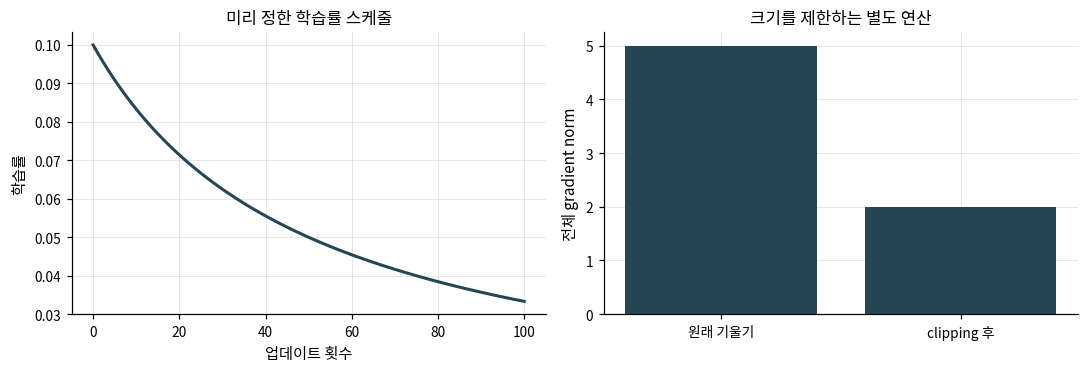

In [29]:
plot_schedule(schedule_steps, rates, np.linalg.norm(large_gradient), np.linalg.norm(clipped))

## 10. 직접 바꾸고 상태를 검산합니다

### 연습 A · Momentum을 직접 작성하기

4절을 가리고 `my_momentum(theta, gradient, state, learning_rate)`를 작성하세요.
반환값은 `(새 theta, 새 state)`이고 state에 `velocity`와 `t`가 있어야 합니다. $\beta=0.9$를 사용합니다.
검사 예제 아래에 새 Code 셀로 자신의 함수를 정의한 뒤 `check_momentum(my_momentum)`을 실행합니다.
첫 스텝은 SGD와 같지만 두 번째부터 이전 상태가 필요합니다.

In [30]:
def check_momentum(candidate):
    theta = np.array([1., -2.])
    first, state = candidate(theta, np.array([2., -4.]), {}, 0.1)
    np.testing.assert_allclose(first, [0.8, -1.6])
    second, state = candidate(first, np.array([-1., 2.]), state, 0.1)
    np.testing.assert_allclose(second, [0.72, -1.44])
    np.testing.assert_allclose(state["velocity"], [0.8, -1.6])
    assert state["t"] == 2
    np.testing.assert_array_equal(theta, [1., -2.])
    print("Momentum: 두 스텝의 상태와 파라미터가 손계산과 일치합니다.")

In [31]:
check_momentum(momentum_step)

Momentum: 두 스텝의 상태와 파라미터가 손계산과 일치합니다.


### 연습 B · Adam의 편향 보정과 스텝 수

`my_adam`을 6절의 함수와 같은 인자로 작성하고 `check_adam(my_adam)`에 전달하세요.
첫 스텝만 보면 상태를 매번 버리는 구현도 알아채기 어렵습니다. 기울기의 부호가 바뀌는 두 번째 스텝까지 검사합니다.
추가로 $\beta_1=0.5$, $\beta_2=0.75$에서 g가 2→1이면 두 번째 보정값은 $\hat m=4/3$, $\hat s=16/7$입니다.
두 beta를 혼동한 풀이를 이 사례로 구분합니다. g와 epsilon이 모두 $10^{-8}$인 첫 스텝에서는 분모가 $2\times10^{-8}$이므로 θ는 1에서 0.95로 변해야 합니다.

In [32]:
def check_adam(candidate):
    options = {"beta1": 0.5, "beta2": 0.5, "epsilon": 0.0}
    first, state = candidate(np.array([1.]), np.array([2.]), {}, 0.1, **options)
    second, state = candidate(first, np.array([-2.]), state, 0.1, **options)
    np.testing.assert_allclose(first, [0.9])
    np.testing.assert_allclose(second, [14/15])
    np.testing.assert_allclose(state["mean"], [-0.5])
    np.testing.assert_allclose(state["square"], [3.])
    assert state["t"] == 2
    # 서로 다른 beta와 크기가 다른 기울기로 두 이동 평균을 구분합니다.
    options = {"beta1": 0.5, "beta2": 0.75, "epsilon": 0.0}
    first, state = candidate(np.array([1.]), np.array([2.]), {}, 0.1, **options)
    np.testing.assert_allclose(state["square"], [1.])
    second, state = candidate(first, np.array([1.]), state, 0.1, **options)
    np.testing.assert_allclose(state["mean"], [1.])
    np.testing.assert_allclose(state["square"], [1.])
    np.testing.assert_allclose(second, [0.9 - np.sqrt(7)/30])
    # 작은 기울기에서는 epsilon의 위치가 관측 가능한 차이를 만듭니다.
    tiny_step, _ = candidate(np.array([1.]), np.array([1e-8]), {}, 0.1, epsilon=1e-8)
    np.testing.assert_allclose(tiny_step, [0.95])
    print("Adam: 두 모멘트·편향 보정·스텝 수·epsilon 위치가 손계산과 일치합니다.")

In [33]:
check_adam(adam_step)

Adam: 두 모멘트·편향 보정·스텝 수·epsilon 위치가 손계산과 일치합니다.


### 연습 C · 배치 크기를 바꾸고 비교 단위를 설명하기

배치를 16에서 8로 바꾸면 65개 표본을 한 번 사용하는 데 5회 대신 9회 업데이트가 필요합니다.
같은 40에폭은 같은 표본 처리량이지만 업데이트 횟수는 다릅니다.
직접 새 schedule을 만들고 8절 함수로 학습한 뒤 `state['t']`, `history['seen'][-1]`과 손실을 확인하세요.
아래 완성 예제를 먼저 실행한 다음 배치 크기를 32 또는 65로 바꿔 보세요.

In [34]:
smaller_schedule = []
rng_smaller = np.random.default_rng(42)
for epoch in range(40):
    smaller_schedule.extend(epoch_batches(len(x_train), 8, rng_smaller))
small_batch_theta, small_batch_state, small_batch_history = train_regression(
    features, targets, initial_theta, smaller_schedule, adam_step, 0.05)
assert small_batch_state["t"] == 9*40
assert small_batch_history["seen"][-1] == 65*40
print("배치 8: steps", small_batch_state["t"], "seen", small_batch_history["seen"][-1],
      "loss", small_batch_history["loss"][-1])

배치 8: steps 360 seen 2600 loss 0.005933663014647557


### 다음으로 가기 전, 네 가지를 따로 확인합니다

- **설명:** loss·backward·optimizer·예측이 각각 무엇을 계산하는지 구분할 수 있나요? → 1·8절
- **수식:** Momentum·RMSProp·Adam을 두 스텝 펼쳐 쓰고, 평균·제곱 평균·편향 보정의 차이를 말할 수 있나요? → 4–6절
- **구현:** 상태를 밖에 유지하고, 마지막 작은 배치에서도 올바른 평균을 내며 갱신할 수 있나요? → 2·8·10절
- **변형:** 배치 크기·학습률·초기화를 바꾸었을 때 비교할 조건과 기록할 값을 정했나요? → 7–10절

이제 공통 기초에서 **계산 구조 → 관측 모형과 목적 → 미분 → 업데이트**를 한 번씩 연결했습니다.
다음 학습 단위는 [전체 경로](../../docs/CURRICULUM.md)의 05 CNN입니다. 지역 연결과 가중치 공유를 배열 연산으로 옮기게 됩니다.

참고: [Hinton 강의의 미니배치·Momentum·RMSProp](https://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf), [Adam 원 논문](https://arxiv.org/abs/1412.6980).
목적·초기값·시드·스텝·학습률은 위 코드에 명시했고 수치는 직접 실행한 결과입니다.